Normalized 5x5 Gaussian kernel (sigma = 2):
[[0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.03832756 0.05576627 0.06319146 0.05576627 0.03832756]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]]
Sum of kernel values: 1.0


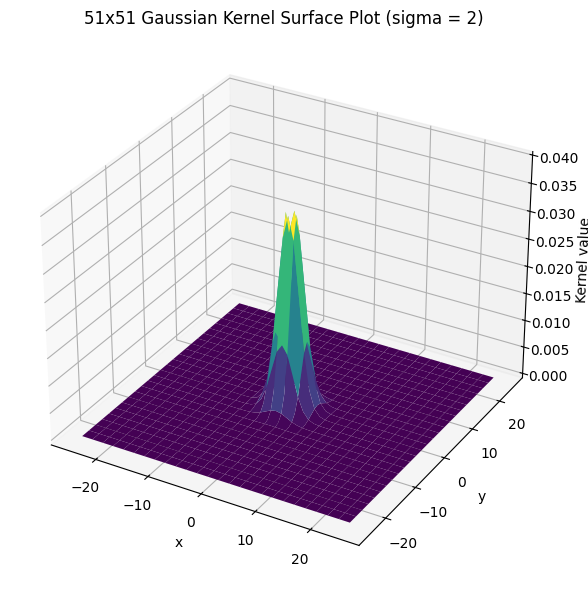

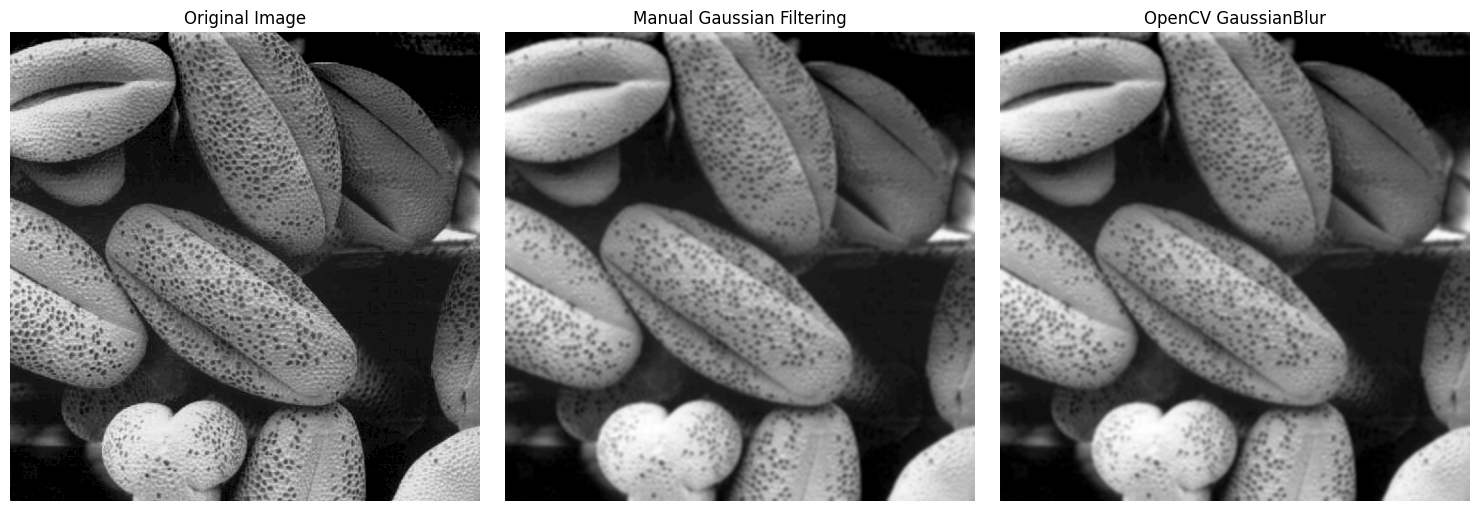

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from google.colab import files



#Create Gaussian kernel
def gaussian_kernel(size, sigma):
    k = size // 2
    x, y = np.mgrid[-k:k+1, -k:k+1]
    kernel = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    kernel = kernel / kernel.sum()   # normalize
    return kernel

#5x5 Gaussian kernel, sigma=2
kernel_5x5 = gaussian_kernel(5, 2)
print("Normalized 5x5 Gaussian kernel (sigma = 2):")
print(kernel_5x5)
print("Sum of kernel values:", kernel_5x5.sum())

#51x51 Gaussian kernel surface plot
kernel_51x51 = gaussian_kernel(51, 2)

x = np.arange(-(51//2), 51//2 + 1)
y = np.arange(-(51//2), 51//2 + 1)
X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, kernel_51x51, cmap='viridis')
ax.set_title("51x51 Gaussian Kernel Surface Plot (sigma = 2)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("Kernel value")
plt.tight_layout()
plt.show()

#Save surface plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, kernel_51x51, cmap='viridis')
ax.set_title("51x51 Gaussian Kernel Surface Plot (sigma = 2)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("Kernel value")
plt.tight_layout()
plt.savefig("q5_gaussian_kernel_surface.png")
plt.close()


#Load grayscale image
img = cv.imread("/content/input_shells.png", cv.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Check the image path. Could not load the grayscale image.")

#Manual Gaussian smoothing using computed kernel
manual_filtered = cv.filter2D(img, -1, kernel_5x5)

#OpenCV GaussianBlur
opencv_filtered = cv.GaussianBlur(img, (5, 5), 2)

# -----------------------------
# Display results
# -----------------------------
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(manual_filtered, cmap='gray')
plt.title("Manual Gaussian Filtering")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(opencv_filtered, cmap='gray')
plt.title("OpenCV GaussianBlur")
plt.axis("off")

plt.tight_layout()
plt.show()


# -----------------------------
# Save outputs
# -----------------------------
cv.imwrite("q5_original.png", img)
cv.imwrite("q5_manual_gaussian.png", manual_filtered)
cv.imwrite("q5_opencv_gaussian.png", opencv_filtered)

# optional comparison figure save
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(manual_filtered, cmap='gray')
plt.title("Manual Gaussian Filtering")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(opencv_filtered, cmap='gray')
plt.title("OpenCV GaussianBlur")
plt.axis("off")

plt.tight_layout()
plt.savefig("q5_filter_comparison.png")
plt.close()